# loading

In [1]:
'''
conda deactivate
conda activate crane_test
srun --nodelist=comput76 --pty -c 4 --mem=50G jupyter lab --no-browser --port=8702 --ip=0.0.0.0
ssh 10.168.203.76 -L 8702:127.0.0.1:8702 #-R 37511:localhost:37511
'''

'\nconda deactivate\nconda activate crane_test\nsrun --nodelist=comput76 --pty -c 4 --mem=50G jupyter lab --no-browser --port=8702 --ip=0.0.0.0\nssh 10.168.203.76 -L 8702:127.0.0.1:8702 #-R 37511:localhost:37511\n'

In [2]:
'''
conda deactivate
conda activate crane_test_r
srun --nodelist=comput107 --pty -c 20 --mem=50G jupyter lab --no-browser --port=8703 --ip=0.0.0.0
ssh 10.168.203.107 -L 8703:127.0.0.1:8703 #-R 37511:localhost:37511
'''

'\nconda deactivate\nconda activate crane_test_r\nsrun --nodelist=comput107 --pty -c 20 --mem=50G jupyter lab --no-browser --port=8703 --ip=0.0.0.0\nssh 10.168.203.107 -L 8703:127.0.0.1:8703 #-R 37511:localhost:37511\n'

In [3]:
import os
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
%matplotlib inline

In [4]:
from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = 'all'  # 默认为'last'，即输出最后一个结果
InteractiveShell.ast_node_interactivity = 'all'

# 1. data 

In [5]:
jcr = pd.read_excel('/public/home/caojun/project/RUSH/1_research/input/JCRImpactFactors2025.xlsx')

In [9]:
num_stat = jcr['Publisher'].value_counts().to_frame(name='num')
num_stat['journal'] = num_stat.index.values.copy()

In [11]:
num_stat

,num,journal
Publisher,,
WILEY,2326,WILEY
ELSEVIER,1679,ELSEVIER
SPRINGER,1565,SPRINGER
"ROUTLEDGE JOURNALS, TAYLOR & FRANCIS LTD",1434,"ROUTLEDGE JOURNALS, TAYLOR & FRANCIS LTD"
TAYLOR & FRANCIS LTD,965,TAYLOR & FRANCIS LTD
...,...,...
"UNIV STUDI NAPOLI FEDERICO II, DIPT PIANIFICAZIONE & SCIENZA TERRITORIO",1,"UNIV STUDI NAPOLI FEDERICO II, DIPT PIANIFICAZ..."
JAPANESE SOC PEDIATRIC ENDOCRINOLOGY,1,JAPANESE SOC PEDIATRIC ENDOCRINOLOGY
JAPAN SOC TROPICAL ECOLOGY,1,JAPAN SOC TROPICAL ECOLOGY


<Figure size 500x1600 with 0 Axes>

<Axes: xlabel='num', ylabel='journal'>

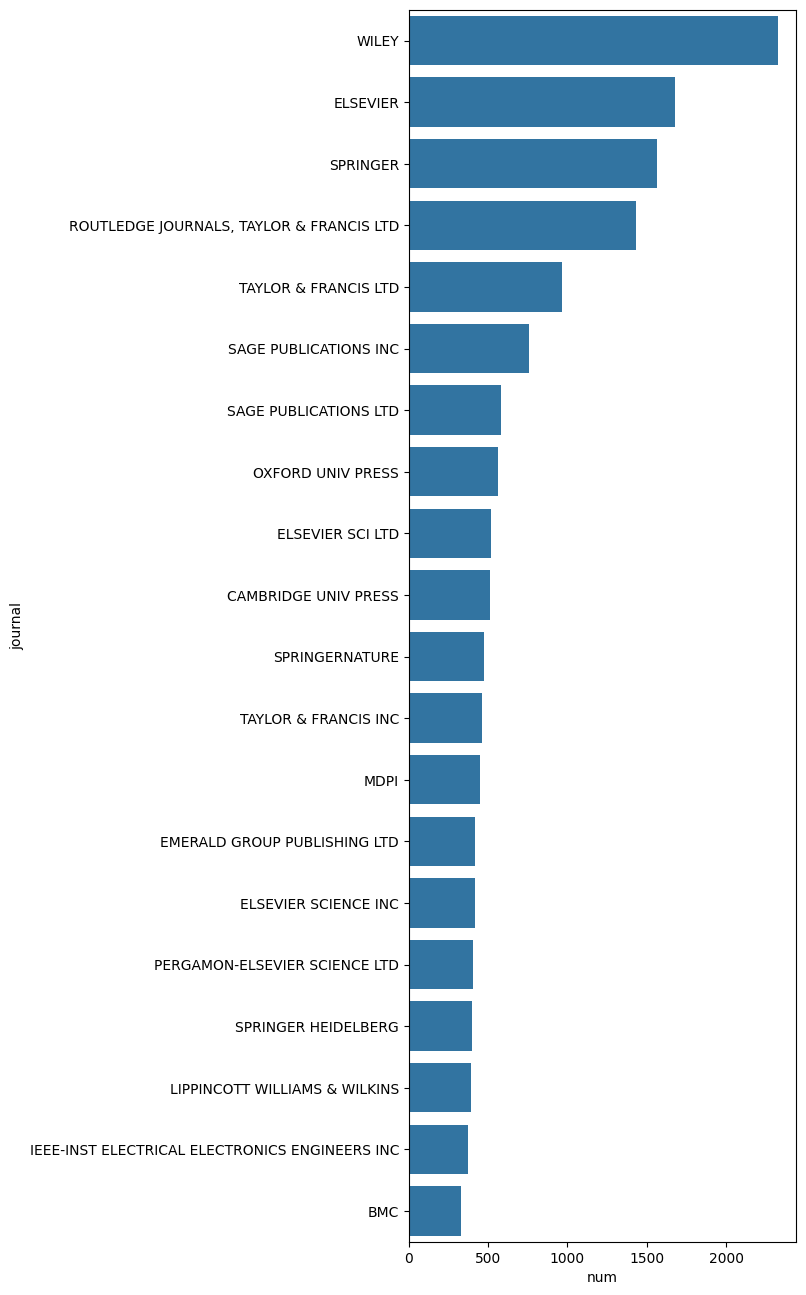

In [15]:
plt.figure(figsize=(5,16))
sns.barplot(
    y=num_stat[num_stat['num'] >300]['journal'],
    x=num_stat[num_stat['num'] >300]['num']
)
plt.show()

In [17]:
journal20 = num_stat[num_stat['num'] > 20]['journal'].to_list()
len(journal20)

129

In [18]:
jcr20 = jcr.loc[jcr['Publisher'].isin(journal20),:]

In [29]:
for jor in journal20:
    jcr_sub = jcr20.loc[jcr20['Publisher']==jor,'5-Year JIF']
    #plt.figure(figsize=(5,1))
    s = jcr_sub.astype(str).str.strip()
    s = s.str.replace(r'^\s*<\s*', '', regex=True)  # 可选：先处理 <
    ifv = pd.to_numeric(s, errors='coerce').dropna().astype(np.float32) 
    #sns.kdeplot(   ifv )
    print(f'{jor}: mean {np.mean(ifv):4f}')
    #plt.title(f'{jor}: {np.mean(ifv)}')
    #plt.show()

WILEY: mean 3.715015
ELSEVIER: mean 5.142403
SPRINGER: mean 3.025580
ROUTLEDGE JOURNALS, TAYLOR & FRANCIS LTD: mean 2.352665
TAYLOR & FRANCIS LTD: mean 2.732703
SAGE PUBLICATIONS INC: mean 3.149516
SAGE PUBLICATIONS LTD: mean 2.740000
OXFORD UNIV PRESS: mean 3.470125
ELSEVIER SCI LTD: mean 5.748638
CAMBRIDGE UNIV PRESS: mean 2.303877
SPRINGERNATURE: mean 5.744132
TAYLOR & FRANCIS INC: mean 2.896288
MDPI: mean 2.936175
EMERALD GROUP PUBLISHING LTD: mean 3.248894
ELSEVIER SCIENCE INC: mean 4.934939
PERGAMON-ELSEVIER SCIENCE LTD: mean 6.044528
SPRINGER HEIDELBERG: mean 2.805012
LIPPINCOTT WILLIAMS & WILKINS: mean 3.375067
IEEE-INST ELECTRICAL ELECTRONICS ENGINEERS INC: mean 5.963144
BMC: mean 5.223547
WALTER DE GRUYTER GMBH: mean 1.312381
BRILL: mean 0.687864
ACADEMIC PRESS INC ELSEVIER SCIENCE: mean 3.608649
FRONTIERS MEDIA SA: mean 3.353658
AMER CHEMICAL SOC: mean 6.964150
IOP Publishing Ltd: mean 3.844872
MARY ANN LIEBERT, INC: mean 2.842857
WILEY-V C H VERLAG GMBH: mean 6.434228
WORLD

In [22]:
jcr_sub.values

array(['353.0', '60.0', '33.2', ..., nan, nan, nan], dtype=object)

In [19]:
jcr20

,Rank,Journal Name,JCR Year,Abbreviated Journal,Publisher,ISSN,eISSN,Total Cites,Total Articles,Citable Items,Cited Half-Life,Citing Half-Life,JIF 2024,5-Year JIF,JIF Without Self-Cites,JCI,JIF Quartile,JIF Rank
0,1,CA-A CANCER JOURNAL FOR CLINICIANS,2024,CA-CANCER J CLIN,WILEY,0007-9235,1542-4863,71799.0,6.0,14.0,3.7,4.7,232.4,353.0,232.2,112.16,Q1,1/326
1,2,NATURE REVIEWS MICROBIOLOGY,2024,NAT REV MICROBIOL,NATURE PORTFOLIO,1740-1526,1740-1534,61109.0,0.0,49.0,6.7,5.4,103.3,99.1,102.8,9.86,Q1,1/163
2,3,NATURE REVIEWS DRUG DISCOVERY,2024,NAT REV DRUG DISCOV,NATURE PORTFOLIO,1474-1776,1474-1784,52833.0,4.0,36.0,6.5,5.4,101.8,129.8,101.1,13.95,Q1,1/352
3,3,NATURE REVIEWS DRUG DISCOVERY,2024,NAT REV DRUG DISCOV,NATURE PORTFOLIO,1474-1776,1474-1784,52833.0,4.0,36.0,6.5,5.4,101.8,129.8,101.1,13.95,Q1,1/352
4,4,NATURE REVIEWS MOLECULAR CELL BIOLOGY,2024,NAT REV MOL CELL BIO,NATURE PORTFOLIO,1471-0072,1471-0080,73135.0,0.0,49.0,7.1,6.9,90.2,128.7,89.6,7.94,Q1,1/204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29263,22189,Natural Language Processing,2024,NAT LANG PROCESS-UK,CAMBRIDGE UNIV PRESS,NaN,2977-0424,3.0,48.0,49.0,NaN,5.7,NaN,NaN,NaN,NaN,NaN,NaN
29265,22189,SCULPTURE MONUMENTS AND OPEN SPACE,2024,SCULPT MONUM OPEN SP,WILEY,2993-3439,2993-3439,1.0,11.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29266,22189,Slavic Literatures,2024,SLAV LITERATURES,ELSEVIER,2950-4244,2950-3965,1.0,29.0,29.0,NaN,29.3,NaN,NaN,NaN,NaN,NaN,NaN
29267,22189,Substance Use & Addiction Journal,2024,SUBST USE ADDICT J,SAGE PUBLICATIONS INC,2976-7342,2976-7350,74.0,109.0,116.0,NaN,5.9,NaN,NaN,NaN,NaN,NaN,NaN


# 2. specific

## 2.1 mdpi

In [31]:
mdpi = jcr20.loc[jcr20['Publisher']=='MDPI',:]

In [32]:
mdpi 

,Rank,Journal Name,JCR Year,Abbreviated Journal,Publisher,ISSN,eISSN,Total Cites,Total Articles,Citable Items,Cited Half-Life,Citing Half-Life,JIF 2024,5-Year JIF,JIF Without Self-Cites,JCI,JIF Quartile,JIF Rank
2147,1232,Antioxidants,2024,ANTIOXIDANTS-BASEL,MDPI,NaN,2076-3921,67105.0,1193.0,1551.0,3.1,6.9,6.6,7.3,6.2,1.19,Q1,8/72
2148,1232,Antioxidants,2024,ANTIOXIDANTS-BASEL,MDPI,NaN,2076-3921,67105.0,1193.0,1551.0,3.1,6.9,6.6,7.3,6.2,1.19,Q1,8/72
2149,1232,Antioxidants,2024,ANTIOXIDANTS-BASEL,MDPI,NaN,2076-3921,67105.0,1193.0,1551.0,3.1,6.9,6.6,7.3,6.2,1.19,Q1,8/72
2607,1484,Machine Learning and Knowledge Extraction,2024,MACH LEARN KNOW EXTR,MDPI,NaN,2504-4990,1846.0,125.0,139.0,2.4,5.3,6.0,5.7,5.9,0.90,Q1,51/366
2608,1484,Machine Learning and Knowledge Extraction,2024,MACH LEARN KNOW EXTR,MDPI,NaN,2504-4990,1846.0,125.0,139.0,2.4,5.3,6.0,5.7,5.9,0.90,Q1,51/366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25195,18332,Humanities-Basel,2024,HUMANITIES-BASEL,MDPI,NaN,2076-0787,587.0,174.0,174.0,6.0,15.9,0.3,0.4,0.3,0.46,NaN,NaN
25631,18332,Surgical Techniques Development,2024,SURG TECH DEV,MDPI,2038-9574,2038-9582,14.0,27.0,32.0,NaN,8.3,0.3,0.3,0.3,0.13,Q4,289/312
26163,19331,Histories,2024,HISTORIES-BASEL,MDPI,NaN,2409-9252,20.0,29.0,30.0,NaN,19.6,0.2,0.2,0.2,0.84,Q2,265/538
26164,19331,Histories,2024,HISTORIES-BASEL,MDPI,NaN,2409-9252,20.0,29.0,30.0,NaN,19.6,0.2,0.2,0.2,0.84,Q2,265/538


In [34]:
mdpi['Journal Name'].unique()

array(['Antioxidants', 'Machine Learning and Knowledge Extraction',
       'Biosensors-Basel', 'Smart Cities', 'Pharmaceutics',
       'Polysaccharides', 'Marine Drugs', 'Gels',
       'Journal of Functional Biomaterials', 'Cells', 'Foods',
       'Microplastics', 'Nutrients', 'AI', 'Polymers', 'Textiles',
       'INTERNATIONAL JOURNAL OF MOLECULAR SCIENCES', 'Pharmaceuticals',
       'Drones', 'Biomolecules', 'Batteries-Basel', 'Clean Technologies',
       'Antibiotics-Basel',
       'Journal of Theoretical and Applied Electronic Commerce Research',
       'MOLECULES', 'Recycling', 'Prosthesis', 'Journal of Xenobiotics',
       'Big Data and Cognitive Computing', 'Cancers', 'Macromol',
       'Medical Sciences', 'Nanomaterials',
       'Journal of Sensor and Actuator Networks', 'Microorganisms',
       'Computers', 'Sustainable Chemistry', 'Plants-Basel',
       'Remote Sensing', 'Toxics',
       'International Journal of Neonatal Screening', 'Journal of Fungi',
       'Toxins', 'Cata

## 2.2 frontier

In [35]:
frontier = jcr20.loc[jcr20['Publisher']=='FRONTIERS MEDIA SA',:]

In [36]:
frontier 

,Rank,Journal Name,JCR Year,Abbreviated Journal,Publisher,ISSN,eISSN,Total Cites,Total Articles,Citable Items,Cited Half-Life,Citing Half-Life,JIF 2024,5-Year JIF,JIF Without Self-Cites,JCI,JIF Quartile,JIF Rank
2666,1529,Frontiers in Immunology,2024,FRONT IMMUNOL,FRONTIERS MEDIA SA,1664-3224,1664-3224,227392.0,3707.0,5098.0,3.6,6.2,5.9,6.8,5.5,1.02,Q1,32/183
3354,1901,Oncology Reviews,2024,ONCOL REV,FRONTIERS MEDIA SA,1970-5565,1970-5557,685.0,7.0,34.0,6.6,6.7,5.2,3.9,5.2,0.44,Q1,64/326
3432,1961,Frontiers in Nutrition,2024,FRONT NUTR,FRONTIERS MEDIA SA,2296-861X,2296-861X,39010.0,1516.0,1809.0,2.6,6.2,5.1,5.4,4.9,0.95,Q1,16/112
3801,2191,Frontiers in Plant Science,2024,FRONT PLANT SCI,FRONTIERS MEDIA SA,1664-462X,1664-462X,147440.0,2439.0,2688.0,4.5,7.5,4.8,5.7,4.5,1.13,Q1,33/273
3802,2191,Frontiers in Pharmacology,2024,FRONT PHARMACOL,FRONTIERS MEDIA SA,NaN,1663-9812,105990.0,2277.0,3155.0,3.5,6.1,4.8,5.2,4.6,1.12,Q1,51/352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18913,11740,Frontiers in Human Dynamics,2024,FRONT HUM DYNAM,FRONTIERS MEDIA SA,NaN,2673-2726,409.0,49.0,60.0,3.2,7.7,1.3,2.1,1.2,0.68,Q3,27/50
19465,11740,Frontiers in Space Technologies,2024,FRONT SPACE TECHNOL,FRONTIERS MEDIA SA,NaN,2673-5075,128.0,23.0,29.0,2.3,8.3,1.3,1.5,1.3,0.24,Q3,33/55
19466,11740,Frontiers in Space Technologies,2024,FRONT SPACE TECHNOL,FRONTIERS MEDIA SA,NaN,2673-5075,128.0,23.0,29.0,2.3,8.3,1.3,1.5,1.3,0.24,Q3,33/55
20970,12843,Frontiers in Urology,2024,FRONT UROL,FRONTIERS MEDIA SA,NaN,2673-9828,152.0,13.0,22.0,1.8,7.9,1.1,1.1,1.1,0.26,Q3,97/133


In [38]:
len(frontier['Journal Name'].unique())

118

In [37]:
frontier['Journal Name'].unique()

array(['Frontiers in Immunology', 'Oncology Reviews',
       'Frontiers in Nutrition', 'Frontiers in Plant Science',
       'Frontiers in Pharmacology',
       'Frontiers in Cellular and Infection Microbiology',
       'Frontiers in Bioengineering and Biotechnology',
       'Frontiers in Artificial Intelligence',
       'BRITISH JOURNAL OF BIOMEDICAL SCIENCE',
       'Frontiers in Endocrinology', 'Frontiers in Toxicology',
       'Frontiers in Aging Neuroscience', 'Frontiers in Microbiology',
       'Frontiers in Genome Editing',
       'JOURNAL OF PHARMACY AND PHARMACEUTICAL SCIENCES',
       'Frontiers in Cell and Developmental Biology',
       'Frontiers in Aging', 'Frontiers in Chemistry',
       'Frontiers in Agronomy', 'Frontiers in Synaptic Neuroscience',
       'Frontiers in Climate', 'PUBLIC HEALTH REVIEWS',
       'Frontiers in Cellular Neuroscience',
       'Frontiers in Molecular Biosciences',
       'Frontiers in Bioinformatics', 'Frontiers in Digital Health',
       'Fron